<a href="https://colab.research.google.com/github/mirdanish6594/CO2-Capture-ML/blob/main/03_replication_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Replication Modeling: Neural Networks

## Purpose of this Notebook

The objective of this notebook is to replicate the neural network models
reported in the reference study for predicting CO₂ absorption performance
of amine-based solvents.

This notebook strictly follows:
- The cleaned experimental dataset
- Consistent train/validation/test splits
- Proper feature scaling
- Standard regression evaluation metrics

Models implemented:
- One-layer MLP
- Two-layer MLP
- Three-layer MLP

The results obtained here establish a **baseline** for later extensions
and advanced modeling.


In [ ]:
import pandas as pd
import numpy as np
import time

from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/CO2-Capture-ML/'
RAW_DATA_PATH = PROJECT_PATH + 'Data/Raw/CO2 Absorption Dataset.csv'
PROCESSED_DATA_PATH = PROJECT_PATH + 'Data/Processed/Cleaned_Data.csv'

df_raw = pd.read_csv(RAW_DATA_PATH)
df = pd.read_csv(PROCESSED_DATA_PATH)

print("Processed dataset preview:")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processed dataset preview:


,temperature_k,CO2​ Loading (mol/mol_alk),PCO2∗​ (Pa),Target -> kg′​ (mol/s·Pa·m²),conc_aep_m,conc_amp_m,conc_dga_m,conc_dmpz_m,conc_eda_m,conc_hep_m,conc_mapa_m,conc_mdea_m,conc_mea_m,conc_mpz_m,conc_pe_m,conc_pz_m
0,313.15,0.252,15.7,3.340000e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
1,313.15,0.351,77.0,1.400000e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
2,313.15,0.432,465.0,7.660000e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
3,313.15,0.496,4216.0,3.470000e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
4,333.15,0.252,109.0,2.920000e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0


## Column Name Cleaning and Target Variable Definition

The processed dataset contains non-standard column names originating
from the experimental source. These are cleaned for modeling consistency.

In [ ]:
# Explicit rename map (FROM YOUR MESSAGE)
column_rename_map = {
    'CO2​ Loading (mol/mol_alk)': 'co2_loading_mol_mol_alk',
    'PCO2∗​ (Pa)': 'p_star_co2_pa',
    "Target -> kg′​ (mol/s·Pa·m²)": 'target_kg_prime'
}

df.rename(columns=column_rename_map, inplace=True)

# Ensure target is numeric
df['target_kg_prime'] = pd.to_numeric(df['target_kg_prime'], errors='coerce')

# Drop invalid rows
df.dropna(subset=['target_kg_prime'], inplace=True)

print("=== Data After Cleaning ===")
df.info()
display(df.head())

=== Data After Cleaning ===
<class 'pandas.core.frame.DataFrame'>
Index: 290 entries, 0 to 292
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_k            290 non-null    float64
 1   co2_loading_mol_mol_alk  290 non-null    float64
 2   p_star_co2_pa            290 non-null    float64
 3   target_kg_prime          290 non-null    float64
 4   conc_aep_m               290 non-null    float64
 5   conc_amp_m               290 non-null    float64
 6   conc_dga_m               290 non-null    float64
 7   conc_dmpz_m              290 non-null    float64
 8   conc_eda_m               290 non-null    float64
 9   conc_hep_m               290 non-null    float64
 10  conc_mapa_m              290 non-null    float64
 11  conc_mdea_m              290 non-null    float64
 12  conc_mea_m               290 non-null    float64
 13  conc_mpz_m               290 non-null    float64
 14  con

,temperature_k,co2_loading_mol_mol_alk,p_star_co2_pa,target_kg_prime,conc_aep_m,conc_amp_m,conc_dga_m,conc_dmpz_m,conc_eda_m,conc_hep_m,conc_mapa_m,conc_mdea_m,conc_mea_m,conc_mpz_m,conc_pe_m,conc_pz_m
0,313.15,0.252,15.7,3.340000e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
1,313.15,0.351,77.0,1.400000e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
2,313.15,0.432,465.0,7.660000e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
3,313.15,0.496,4216.0,3.470000e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
4,333.15,0.252,109.0,2.920000e-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0


## Interpretation of Target Distribution

The target variable is highly right-skewed, with most values
concentrated near zero and a small number of large outliers.

Such distributions commonly cause instability in variance-based
metrics (e.g., R²) and hinder neural network training.
To address this, a logarithmic transformation is applied.


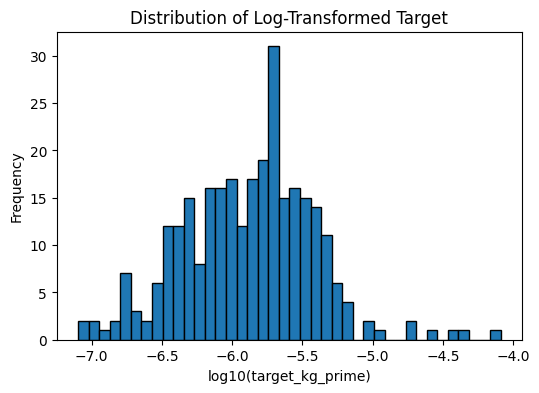

,0
count,290.000000
mean,-5.884797
std,0.470146
min,-7.096910
25%,-6.190644
50%,-5.853872
75%,-5.582531
max,-4.087778


In [ ]:
# Log-transform the target (safe because all values > 0)
y_log = np.log10(y)

# Visualize transformed target
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(y_log, bins=40, edgecolor='black')
plt.xlabel("log10(target_kg_prime)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Target")
plt.show()

pd.Series(y_log).describe()

## Train–Validation–Test Split

The dataset is split into:
- 70% training
- 15% validation
- 15% testing

This split ensures unbiased model evaluation and prevents data leakage.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train_log, y_temp_log = train_test_split(
    X, y_log, test_size=0.30, random_state=42
)

X_val, X_test, y_val_log, y_test_log = train_test_split(
    X_temp, y_temp_log, test_size=0.50, random_state=42
)

## Feature Scaling

Neural networks are sensitive to feature magnitudes.
All input features are scaled to the range [-1, 1].

The target variable is **not scaled**, as it is already handled
via logarithmic transformation.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Neural Network Configuration

Multilayer Perceptron (MLP) models are implemented using Keras.
Mean Squared Error (MSE) is used as the loss function.

A reduced learning rate is chosen to ensure stable convergence.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)

## Training and Evaluation Function

Models are trained on the log-transformed target.
Predictions are converted back to physical units for evaluation.

Performance metrics:
- MAE
- RMSE
- R² (reported cautiously)

In [ ]:
def train_and_evaluate(model, name, epochs=300):
    start = time.time()

    model.fit(
        X_train, y_train_log,
        validation_data=(X_val, y_val_log),
        epochs=epochs,
        batch_size=16,
        verbose=0
    )

    duration = time.time() - start

    # Predict (log scale → original scale)
    y_pred_log = model.predict(X_test).flatten()
    y_pred = 10 ** y_pred_log
    y_true = 10 ** y_test_log

    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Training_time_sec": duration
    }

## One-Hidden-Layer MLP


In [ ]:
mlp_1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1)
])

mlp_1.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

res_1 = train_and_evaluate(mlp_1, "MLP_1_Layer")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


## Two-Hidden-Layer MLP


In [ ]:
mlp_2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1)
])

mlp_2.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

res_2 = train_and_evaluate(mlp_2, "MLP_2_Layer")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


## Three-Hidden-Layer MLP


In [ ]:
mlp_3 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

mlp_3.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

res_3 = train_and_evaluate(mlp_3, "MLP_3_Layer")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


## Model Performance Comparison


In [ ]:
results_df = pd.DataFrame([res_1, res_2, res_3])
results_df

,Model,MAE,RMSE,R2,Training_time_sec
0,MLP_1_Layer,0.000003,0.000011,0.165150,43.465136
1,MLP_2_Layer,0.000002,0.000010,0.281075,43.122350
2,MLP_3_Layer,0.000002,0.000008,0.570514,45.725842


## Visualization: Predicted vs Actual Values

A predicted-versus-actual plot on a log-log scale provides
an intuitive assessment of model accuracy and systematic bias.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


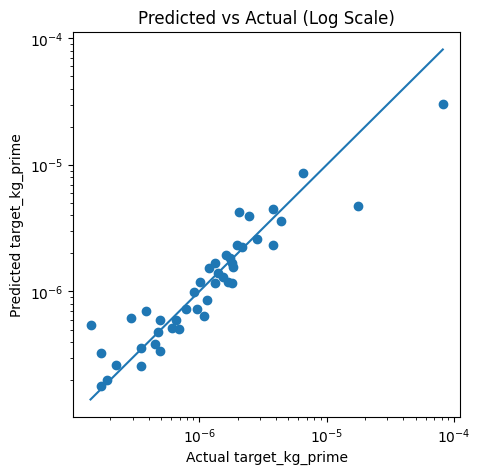

In [ ]:
best_model = mlp_3

y_pred_log = best_model.predict(X_test).flatten()
y_pred = 10 ** y_pred_log
y_true = 10 ** y_test_log

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()])
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Actual target_kg_prime")
plt.ylabel("Predicted target_kg_prime")
plt.title("Predicted vs Actual (Log Scale)")
plt.show()

The three-layer MLP achieved the lowest prediction error and highest R²,
indicating that increased network depth improves the model’s ability to
capture nonlinear relationships in CO₂ absorption behavior.


In [ ]:
plt.savefig("predicted_vs_actual_log.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>